In [32]:
# Nếu chạy lần đầu trên Colab/local, mở comment dòng dưới để cài dependency.
# !pip install opencv-python ultralytics transformers torch pillow matplotlib

In [33]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from transformers import pipeline
from ultralytics import YOLO

In [34]:
# Load YOLO model và gender recognition model
# YOLO class 0 trong COCO là person.
def resolve_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    return Path(candidates[0])

yolo_model = YOLO("yolo26n.pt")

GENDER_MODEL_ID = 'rizvandwiki/gender-classification'
device = 0 if torch.cuda.is_available() else -1
gender_model = pipeline('image-classification', model=GENDER_MODEL_ID, device=device)

print(f'YOLO classes: {len(yolo_model.names)}')
print(f'Gender model: {GENDER_MODEL_ID}')

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 9260.58it/s]


YOLO classes: 80
Gender model: rizvandwiki/gender-classification


In [35]:
def detect_person_objects(image_bgr, model, conf=0.25):
    """Detect person objects and return a list of cropped person objects."""
    results = model.predict(image_bgr, classes=[0], conf=conf, verbose=False)
    detections = results[0]
    person_objects = []

    h, w = image_bgr.shape[:2]
    boxes = detections.boxes
    if boxes is None or len(boxes) == 0:
        return person_objects, detections

    xyxy_values = boxes.xyxy.cpu().numpy().astype(int)
    confidence_values = boxes.conf.cpu().numpy()
    class_values = boxes.cls.cpu().numpy().astype(int)

    for idx, (xyxy, confidence, class_id) in enumerate(zip(xyxy_values, confidence_values, class_values), start=1):
        label = detections.names.get(int(class_id), str(class_id))
        if label != 'person':
            continue

        x1, y1, x2, y2 = xyxy.tolist()
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        crop_bgr = image_bgr[y1:y2, x1:x2].copy()
        if crop_bgr.size == 0:
            continue

        person_objects.append({
            'id': idx,
            'bbox': (x1, y1, x2, y2),
            'confidence': float(confidence),
            'crop_bgr': crop_bgr,
        })

    return person_objects, detections


def predict_gender_for_objects(person_objects, classifier):
    """Run gender recognition on each person crop and append labels/scores."""
    for obj in person_objects:
        crop_rgb = cv2.cvtColor(obj['crop_bgr'], cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(crop_rgb)
        predictions = classifier(pil_image)
        best = max(predictions, key=lambda item: item['score'])

        obj['gender_label'] = best['label']
        obj['gender_score'] = float(best['score'])
        obj['gender_predictions'] = predictions

    return person_objects


def build_person_matrices(person_objects, resize_to=(224, 224)):
    """Create crop collections as array/list and fixed-size tensor matrix."""
    person_crop_array = np.array([obj['crop_bgr'] for obj in person_objects], dtype=object)

    resized_crops = []
    for obj in person_objects:
        resized = cv2.resize(obj['crop_bgr'], resize_to)
        resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        resized_crops.append(resized_rgb)

    resized_matrix = np.stack(resized_crops, axis=0) if resized_crops else np.empty((0, *resize_to, 3), dtype=np.uint8)
    return person_crop_array, resized_matrix


def draw_gender_labels(image_bgr, person_objects):
    annotated = image_bgr.copy()
    for obj in person_objects:
        x1, y1, x2, y2 = obj['bbox']
        label = f"{obj['gender_label']} {obj['gender_score']:.2f}"
        conf = f"person {obj['confidence']:.2f}"

        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 180, 255), 2)
        cv2.putText(annotated, label, (x1, max(20, y1 - 28)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 180, 255), 2)
        cv2.putText(annotated, conf, (x1, max(20, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)
    return annotated


def show_bgr(image_bgr, title='', figsize=(12, 8)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    plt.show()

Number of persons detected: 3
person_crop_array shape: (3,)
person_resized_matrix shape: (3, 224, 224, 3)  # (N, H, W, C)
Person 1: bbox=(22, 27, 402, 748), YOLO confidence=0.946, gender=male (0.986)
Person 2: bbox=(350, 103, 709, 741), YOLO confidence=0.943, gender=female (0.985)
Person 3: bbox=(649, 151, 925, 746), YOLO confidence=0.924, gender=female (0.985)


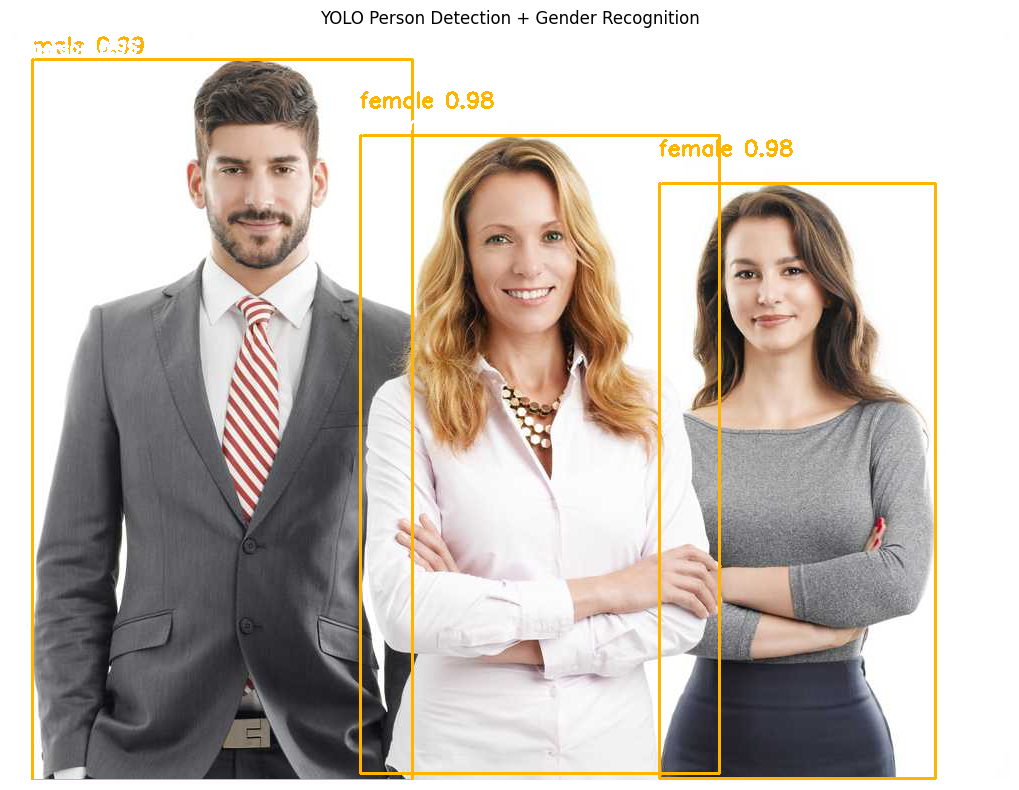

In [36]:
# Detect person, crop/slice từng object người thành array/matrix, nhận diện gender và label trên ảnh.
img_path = resolve_path('data/people.jpg', 'day-5/data/people.jpg')
image = cv2.imread(str(img_path))

if image is None:
    print(f'Image not found at {img_path}')
else:
    person_objects, yolo_result = detect_person_objects(image, yolo_model, conf=0.25)
    person_objects = predict_gender_for_objects(person_objects, gender_model)

    # Array object chứa crop gốc với kích thước khác nhau: shape = (N,)
    person_crop_array, person_resized_matrix = build_person_matrices(person_objects, resize_to=(224, 224))

    print(f'Number of persons detected: {len(person_objects)}')
    print(f'person_crop_array shape: {person_crop_array.shape}')
    print(f'person_resized_matrix shape: {person_resized_matrix.shape}  # (N, H, W, C)')

    for obj in person_objects:
        print(
            f"Person {obj['id']}: bbox={obj['bbox']}, "
            f"YOLO confidence={obj['confidence']:.3f}, "
            f"gender={obj['gender_label']} ({obj['gender_score']:.3f})"
        )

    annotated_image = draw_gender_labels(image, person_objects)
    show_bgr(annotated_image, 'YOLO Person Detection + Gender Recognition')

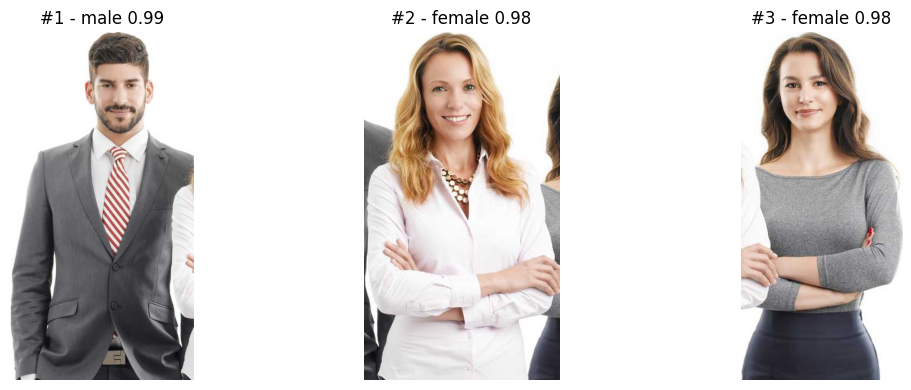

In [37]:
# Hiển thị từng crop người đã được YOLO slice ra từ ảnh.
if 'person_objects' in globals() and person_objects:
    cols = min(4, len(person_objects))
    rows = int(np.ceil(len(person_objects) / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, obj in enumerate(person_objects, start=1):
        crop_rgb = cv2.cvtColor(obj['crop_bgr'], cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i)
        plt.imshow(crop_rgb)
        plt.title(f"#{obj['id']} - {obj['gender_label']} {obj['gender_score']:.2f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No person crops to display.')

Frame 0 (0.00s): 10 person(s), matrix=(10, 224, 224, 3)
  Person 1: bbox=(88, 237, 199, 568), YOLO=0.902, gender=male (0.973)
  Person 2: bbox=(220, 243, 330, 565), YOLO=0.899, gender=male (0.980)
  Person 3: bbox=(1101, 67, 1279, 712), YOLO=0.842, gender=female (0.970)
  Person 4: bbox=(341, 231, 447, 555), YOLO=0.831, gender=male (0.977)
  Person 5: bbox=(480, 275, 592, 523), YOLO=0.772, gender=male (0.975)
  Person 6: bbox=(942, 300, 1014, 489), YOLO=0.749, gender=male (0.523)
  Person 7: bbox=(896, 290, 937, 432), YOLO=0.605, gender=male (0.823)
  Person 8: bbox=(578, 130, 758, 717), YOLO=0.600, gender=male (0.935)
  Person 9: bbox=(423, 292, 476, 497), YOLO=0.444, gender=male (0.588)
  Person 10: bbox=(525, 275, 594, 499), YOLO=0.329, gender=male (0.969)
Frame 5 (0.17s): 11 person(s), matrix=(11, 224, 224, 3)
  Person 1: bbox=(90, 243, 198, 569), YOLO=0.904, gender=male (0.969)
  Person 2: bbox=(213, 250, 326, 564), YOLO=0.902, gender=male (0.975)
  Person 3: bbox=(478, 288, 584, 

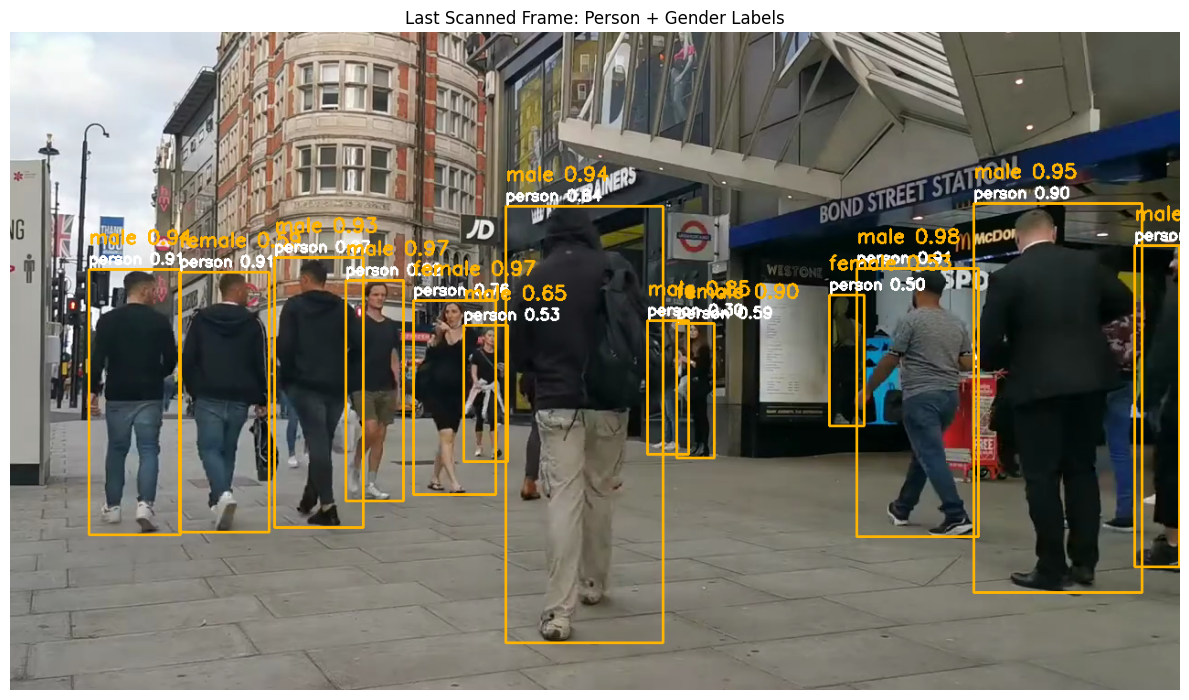

In [40]:
# Apply predict_gender_for_objects cho video.
# Cấu hình: quét mỗi 5 frame và chỉ quét trong N giây đầu video.
video_path = resolve_path('data/people_video.mp4', 'day-5/data/people_video.mp4')
detect_every_n_frames = 5
scan_duration_seconds = 1  # đổi số giây muốn quét; đặt None để quét toàn bộ video

cap = cv2.VideoCapture(str(video_path))

if not cap.isOpened():
    print(f'Video not found or cannot be opened: {video_path}')
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    max_scan_frames = total_frames
    if scan_duration_seconds is not None:
        max_scan_frames = min(total_frames, int(scan_duration_seconds * fps))

    frame_id = 0
    scanned_frame_count = 0
    last_annotated = None
    video_gender_results = []

    while frame_id < max_scan_frames:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_id % detect_every_n_frames == 0:
            frame_objects, _ = detect_person_objects(frame, yolo_model, conf=0.25)
            frame_objects = predict_gender_for_objects(frame_objects, gender_model)
            frame_crop_array, frame_resized_matrix = build_person_matrices(frame_objects, resize_to=(224, 224))

            frame_second = frame_id / fps
            video_gender_results.append({
                'frame_id': frame_id,
                'second': frame_second,
                'objects': frame_objects,
                'crop_array': frame_crop_array,
                'resized_matrix': frame_resized_matrix,
            })

            scanned_frame_count += 1
            last_annotated = draw_gender_labels(frame, frame_objects)

            print(f'Frame {frame_id} ({frame_second:.2f}s): {len(frame_objects)} person(s), matrix={frame_resized_matrix.shape}')
            for obj in frame_objects:
                print(
                    f"  Person {obj['id']}: bbox={obj['bbox']}, "
                    f"YOLO={obj['confidence']:.3f}, "
                    f"gender={obj['gender_label']} ({obj['gender_score']:.3f})"
                )

        frame_id += 1

    cap.release()

    print(f'\nScanned {scanned_frame_count} frame(s) from {video_path}')
    print(f'video_gender_results length: {len(video_gender_results)}')

    if last_annotated is not None:
        show_bgr(last_annotated, 'Last Scanned Frame: Person + Gender Labels')
    else:
        print('No frames were scanned from the video.')

In [ ]:
# Compare prediction results from pretrained YOLO and finetuned YOLO.
model_pre_path = resolve_path('yolo26n.pt', 'day-5/yolo26n.pt')
model_finetuned_path = resolve_path('data/yolo11n_finetuned.pt', 'day-5/data/yolo11n_finetuned.pt')
image_path = resolve_path('data/x.avif', 'day-5/data/x.avif')

model_pre = YOLO(str(model_pre_path))
model_finetuned = YOLO(str(model_finetuned_path))

results_pre = model_pre.predict(str(image_path), imgsz=640, save=False, verbose=False)
results_ft = model_finetuned.predict(str(image_path), imgsz=640, save=False, verbose=False)

img_pre = results_pre[0].plot()
img_ft = results_ft[0].plot()

img_pre = cv2.cvtColor(img_pre, cv2.COLOR_BGR2RGB)
img_ft = cv2.cvtColor(img_ft, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img_pre)
axes[0].set_title('Pretrained YOLO', fontsize=14)
axes[0].axis('off')

axes[1].imshow(img_ft)
axes[1].set_title('Finetuned YOLO', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Pretrained detections: {len(results_pre[0].boxes)}')
print(f'Finetuned detections: {len(results_ft[0].boxes)}')